# Kou Calibration Diagnostics and the Spread Direction

This notebook illustrates the calibration ideas moved to **Appendix A of the paper**. It uses the saved calibrated model for diagnostics and also runs a small synthetic calibration example to demonstrate the estimator API:

1. simulated bivariate Kou returns and their spread;
2. the standardized ECF frequency grid;
3. empirical-versus-model characteristic-function diagnostics along \((s,-s)\), the liquidation-relevant spread direction.

## 1. Setup and calibrated parameter table

In [1]:
from pathlib import Path
import sys

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "optimal_long_short").exists() and (path / "results").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.spines.top": False, "axes.spines.right": False})

from optimal_long_short.calibration import StandardizedCalibrationGrid, empirical_cf
from optimal_long_short.job_runners.common import load_calibrated_params
from optimal_long_short.kou_model import BivariateKouModel
from optimal_long_short.simulation import simulate_kou_returns

params, constraint = load_calibrated_params(ROOT / "results" / "params_WBTC_WETH.json")
parameter_table = pd.DataFrame({
    "asset 1 (WBTC)": [params.mu1, params.muX1, params.sigma1, params.lam1, params.p1, params.eta1_pos, params.eta1_neg],
    "asset 2 (WETH)": [params.mu2, params.muX2, params.sigma2, params.lam2, params.p2, params.eta2_pos, params.eta2_neg],
}, index=["price-growth mu", "log-process muX", "sigma", "lambda", "p(up)", "eta_pos", "eta_neg"])
parameter_table.style.format(precision=5)

,asset 1 (WBTC),asset 2 (WETH)
price-growth mu,0.48709,1.19963
log-process muX,-0.30543,0.25712
sigma,0.24138,0.30707
lambda,372.95392,588.94800
p(up),0.50779,0.35712
eta_pos,0.01105,0.01249
eta_neg,0.00743,0.00469


## 2. Simulate returns and inspect the liquidation-relevant spread

In [2]:
rng = np.random.default_rng(42)
dt = 4.0 / (365.0 * 24.0)
r1, r2 = simulate_kou_returns(params, n=20_000, dt=dt, rng=rng)
z = r1 - r2

summary = pd.DataFrame({
    "WBTC return": pd.Series(r1).describe(percentiles=[0.01, 0.05, 0.95, 0.99]),
    "WETH return": pd.Series(r2).describe(percentiles=[0.01, 0.05, 0.95, 0.99]),
    "spread Z": pd.Series(z).describe(percentiles=[0.01, 0.05, 0.95, 0.99]),
})
summary.style.format(precision=6)

,WBTC return,WETH return,spread Z
count,20000.000000,20000.000000,20000.000000
mean,0.000252,0.000556,-0.000305
std,0.007605,0.009108,0.009011
min,-0.052865,-0.048592,-0.086368
1%,-0.017377,-0.018839,-0.032992
5%,-0.009955,-0.012327,-0.012813
95%,0.010817,0.014282,0.011342
99%,0.025874,0.031642,0.027085
max,0.088221,0.088999,0.082122


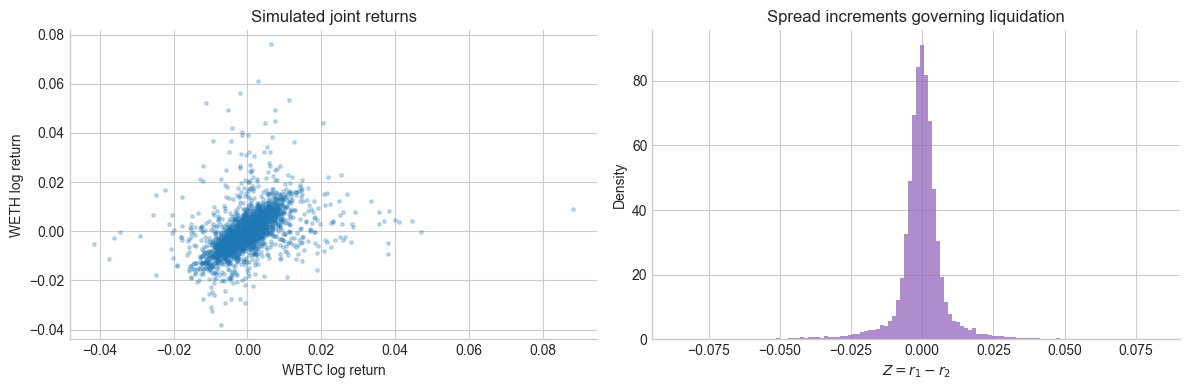

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(r1[:2500], r2[:2500], s=6, alpha=0.25)
axes[0].set(xlabel="WBTC log return", ylabel="WETH log return", title="Simulated joint returns")
axes[1].hist(z, bins=120, density=True, color="tab:purple", alpha=0.75)
axes[1].set(xlabel="$Z = r_1-r_2$", ylabel="Density", title="Spread increments governing liquidation")
fig.tight_layout()
plt.show()

## 3. Standardized calibration frequency grid

The grid contains marginal, joint, spread, and jump-tail groups. Standardization makes the same base grid usable across return frequencies.

In [4]:
grid = StandardizedCalibrationGrid()
freqs, weights, groups, scale_info = grid.build_from_returns(r1, r2)
grid_table = pd.DataFrame({"group": groups, "u": freqs[:, 0], "v": freqs[:, 1], "weight": weights})
counts = grid_table.groupby("group").agg(points=("group", "size"), mean_weight=("weight", "mean"), max_abs_u=("u", lambda x: np.abs(x).max()), max_abs_v=("v", lambda x: np.abs(x).max()))
print("Robust scales:", scale_info)
counts.style.format(precision=3)

Robust scales: {'s1': 0.005712427857389285, 's2': 0.007312798803831706, 'sz': 0.004583073595982848}


,points,mean_weight,max_abs_u,max_abs_v
group,,,,
joint_pm,72,0.792,875.285,683.733
joint_pp,72,0.792,875.285,683.733
jump_tail,28,0.054,4376.423,4363.884
marginal_1,22,0.795,1750.569,0.000
marginal_2,22,0.795,0.000,1367.465
spread,18,1.724,1090.971,1090.971


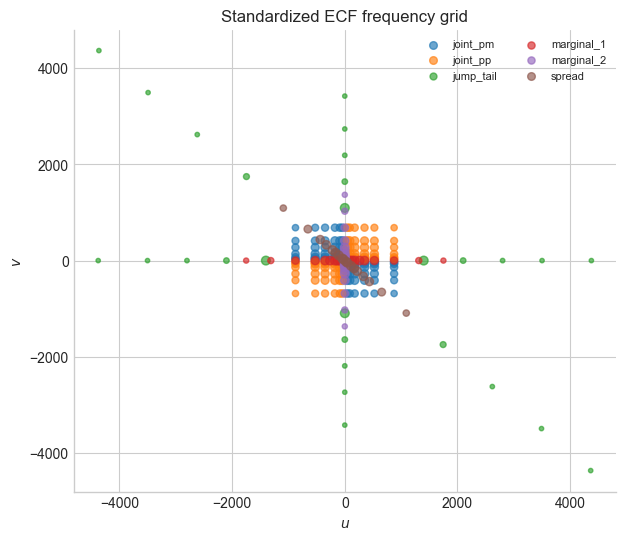

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for group, frame in grid_table.groupby("group"):
    ax.scatter(frame["u"], frame["v"], s=10 + 30 * frame["weight"] / frame["weight"].max(), alpha=0.65, label=group)
ax.set(xlabel="$u$", ylabel="$v$", title="Standardized ECF frequency grid")
ax.legend(fontsize=8, ncol=2)
plt.show()

## 4. ECF diagnostic along the spread direction

Along \((s,-s)\), the characteristic function directly probes \(Z=X_1-X_2\), which drives the health-factor barrier.

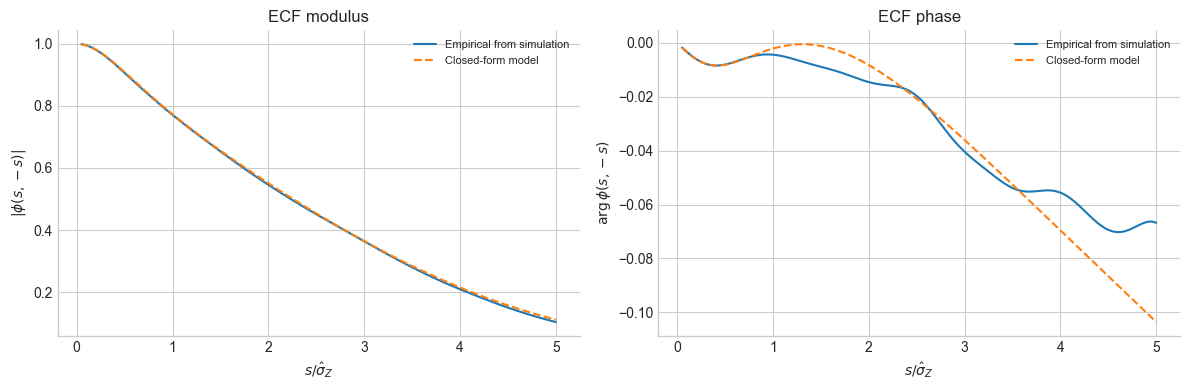

In [6]:
model = BivariateKouModel(params)
sz = np.std(z, ddof=1)
s_scaled = np.linspace(0.05, 5.0, 180)
s = s_scaled / sz
spread_freqs = np.column_stack([s, -s])
phi_emp = empirical_cf(r1, r2, spread_freqs)
phi_model = np.array([np.exp(dt * model.levy_khintchine(x, -x)) for x in s])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s_scaled, np.abs(phi_emp), label="Empirical from simulation")
axes[0].plot(s_scaled, np.abs(phi_model), ls="--", label="Closed-form model")
axes[0].set(xlabel=r"$s / \hat{\sigma}_Z$", ylabel=r"$|\phi(s,-s)|$", title="ECF modulus")
axes[1].plot(s_scaled, np.angle(phi_emp), label="Empirical from simulation")
axes[1].plot(s_scaled, np.angle(phi_model), ls="--", label="Closed-form model")
axes[1].set(xlabel=r"$s / \hat{\sigma}_Z$", ylabel=r"$\arg\phi(s,-s)$", title="ECF phase")
for ax in axes: ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5. Run a small ECF calibration

The full empirical job uses more observations and many optimizer starts. For a tutorial-sized run, call `calibrate_ecf` with a small synthetic sample and inspect the returned `ECFCalibrationResult`.

In [7]:
from optimal_long_short.calibration import calibrate_ecf

# Use a small subset so this tutorial cell runs quickly.
calibration_result = calibrate_ecf(
    r1[:500],
    r2[:500],
    dt_years=dt,
    n_starts=2,
    seed=7,
    run_diagnostics=False,
    max_moment_order=4,
)

pd.Series({
    "success": calibration_result.success,
    "objective": calibration_result.objective,
    "iterations": calibration_result.n_iter,
    "best start index": calibration_result.best_start_index,
    "observations": calibration_result.n_obs,
    "frequency points": len(calibration_result.freqs),
}).to_frame("calibration result")

,calibration result
success,True
objective,0.001541
iterations,74
best start index,0
observations,500
frequency points,234


In [8]:
# Tabulate selected fitted parameters against the data-generating model.
fitted = calibration_result.params
fit_table = pd.DataFrame({
    "data-generating value": [params.sigma1, params.lam1, params.eta1_neg, params.sigma2, params.lam2, params.eta2_pos, params.rho],
    "fitted value": [fitted.sigma1, fitted.lam1, fitted.eta1_neg, fitted.sigma2, fitted.lam2, fitted.eta2_pos, fitted.rho],
}, index=["sigma1", "lambda1", "eta1_neg", "sigma2", "lambda2", "eta2_pos", "rho"])
fit_table["relative difference"] = (fit_table["fitted value"] - fit_table["data-generating value"]) / fit_table["data-generating value"]
fit_table.style.format(precision=5)

,data-generating value,fitted value,relative difference
sigma1,0.24138,0.24179,0.00168
lambda1,372.95392,78.49595,-0.78953
eta1_neg,0.00743,0.00272,-0.63346
sigma2,0.30707,0.30412,-0.00963
lambda2,588.94800,283.96249,-0.51785
eta2_pos,0.01249,0.00498,-0.60126
rho,0.85756,0.73279,-0.14550


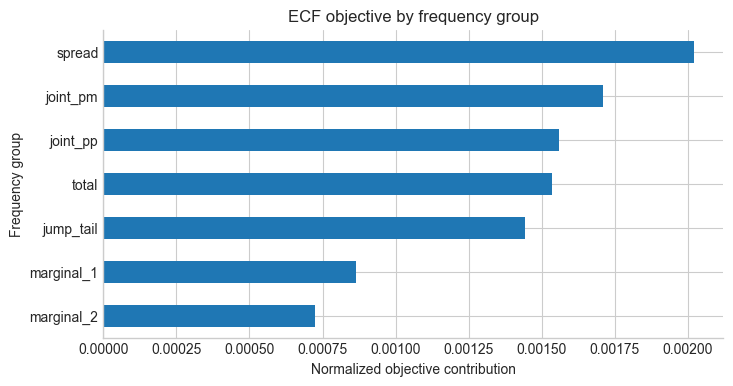

In [9]:
group_objective = pd.Series(calibration_result.objective_by_group).sort_values()
ax = group_objective.plot.barh(figsize=(8, 4), title="ECF objective by frequency group")
ax.set(xlabel="Normalized objective contribution", ylabel="Frequency group")
plt.show()

`ECFCalibrationResult` also retains the fitted frequency grid, weights, initialization point, optimizer-start objectives, and optional diagnostics, so downstream reporting does not need to rerun calibration.

## 6. Quantile diagnostic and takeaway

In [10]:
quantiles = [0.01, 0.05, 0.50, 0.95, 0.99]
q = pd.DataFrame({
    "quantile": quantiles,
    "simulated spread": np.quantile(z, quantiles),
})
q.style.format({"quantile": "{:.0%}", "simulated spread": "{:.6f}"})

,quantile,simulated spread
0,1%,-0.032992
1,5%,-0.012813
2,50%,-0.000116
3,95%,0.011342
4,99%,0.027085


The spread-direction ECF and tail quantiles are especially important for liquidation applications because they diagnose the process that crosses the barrier, rather than only the two marginal return laws.